In [278]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [279]:
df = pd.read_csv("Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [280]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [281]:
df.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [282]:
df["Extracurricular Activities encoded"] = df["Extracurricular Activities"].map({"Yes":1, 
                                                                                 "No": 0})
df["Extracurricular Activities encoded"]

0       1
1       0
2       1
3       1
4       0
       ..
9995    1
9996    1
9997    1
9998    1
9999    0
Name: Extracurricular Activities encoded, Length: 10000, dtype: int64

In [283]:
df.duplicated().sum()

np.int64(127)

In [284]:
df.drop_duplicates(inplace= True)

In [285]:
df.duplicated().sum()

np.int64(0)

In [286]:
means = []
stds = []
for column in np.array(["Hours Studied", "Previous Scores", "Sleep Hours", "Sample Question Papers Practiced"]):
    mean = df[column].mean()
    std = df[column].std()
    means.append(mean)
    stds.append(std)
    df[column] = (df[column] - mean) / std

In [287]:
df.drop(columns=["Extracurricular Activities"], inplace=True)
df.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities encoded
0,0.775526,1.706082,1.453951,-1.249652,91.0,1
1,-0.383186,0.724875,-1.491240,-0.900880,65.0,0
2,1.161764,-1.064385,0.275875,-0.900880,45.0,1
3,0.003051,-1.006666,-0.902201,-0.900880,36.0,1
4,0.775526,0.320849,0.864913,0.145436,66.0,0


In [288]:
target = np.array(df["Performance Index"])
target

array([91., 65., 45., ..., 74., 95., 64.], shape=(9873,))

In [289]:
X = np.array(df.drop(columns=["Performance Index"]))
print(X)
print(X.shape)

[[ 0.77552623  1.70608209  1.45395119 -1.24965162  1.        ]
 [-0.38318601  0.72487516 -1.49123964 -0.9008796   0.        ]
 [ 1.16176364 -1.06438453  0.27587486 -0.9008796   1.        ]
 ...
 [ 0.38928882  0.78259322  0.86491302  0.14543649  1.        ]
 [ 1.54800105  1.59064598  0.27587486 -1.59842365  1.        ]
 [ 0.77552623  0.26313072  0.86491302 -1.24965162  0.        ]]
(9873, 5)


In [290]:
weights = np.zeros(X.shape[1] + 1)
weights.shape

(6,)

In [291]:
bias = np.ones((X.shape[0], 1))
bias.shape

(9873, 1)

In [292]:
X = np.hstack((bias, X))
print(X)
print(X.shape)

[[ 1.          0.77552623  1.70608209  1.45395119 -1.24965162  1.        ]
 [ 1.         -0.38318601  0.72487516 -1.49123964 -0.9008796   0.        ]
 [ 1.          1.16176364 -1.06438453  0.27587486 -0.9008796   1.        ]
 ...
 [ 1.          0.38928882  0.78259322  0.86491302  0.14543649  1.        ]
 [ 1.          1.54800105  1.59064598  0.27587486 -1.59842365  1.        ]
 [ 1.          0.77552623  0.26313072  0.86491302 -1.24965162  0.        ]]
(9873, 6)


In [293]:
h_of_x = X @ weights
print(h_of_x)

[0. 0. 0. ... 0. 0. 0.]


In [294]:
deltas = h_of_x - target
print(deltas)

[-91. -65. -45. ... -74. -95. -64.]


In [295]:
learning_rate = 0.0001
for i in range(0, 10000):
    h_of_x = X @ weights
    deltas = h_of_x - target
    for index in range(0, weights.shape[0]):
        gradient = deltas * X[:, index]
        weights[index] = weights[index] - learning_rate * gradient.sum()

In [296]:
predictions = X @ weights
print(predictions)

[91.84730508 63.15329913 45.05396752 ... 72.9967841  94.36157068
 65.29230415]


In [297]:
error = predictions - target
mse = (error ** 2).mean()
print(mse)

4.175798212131155


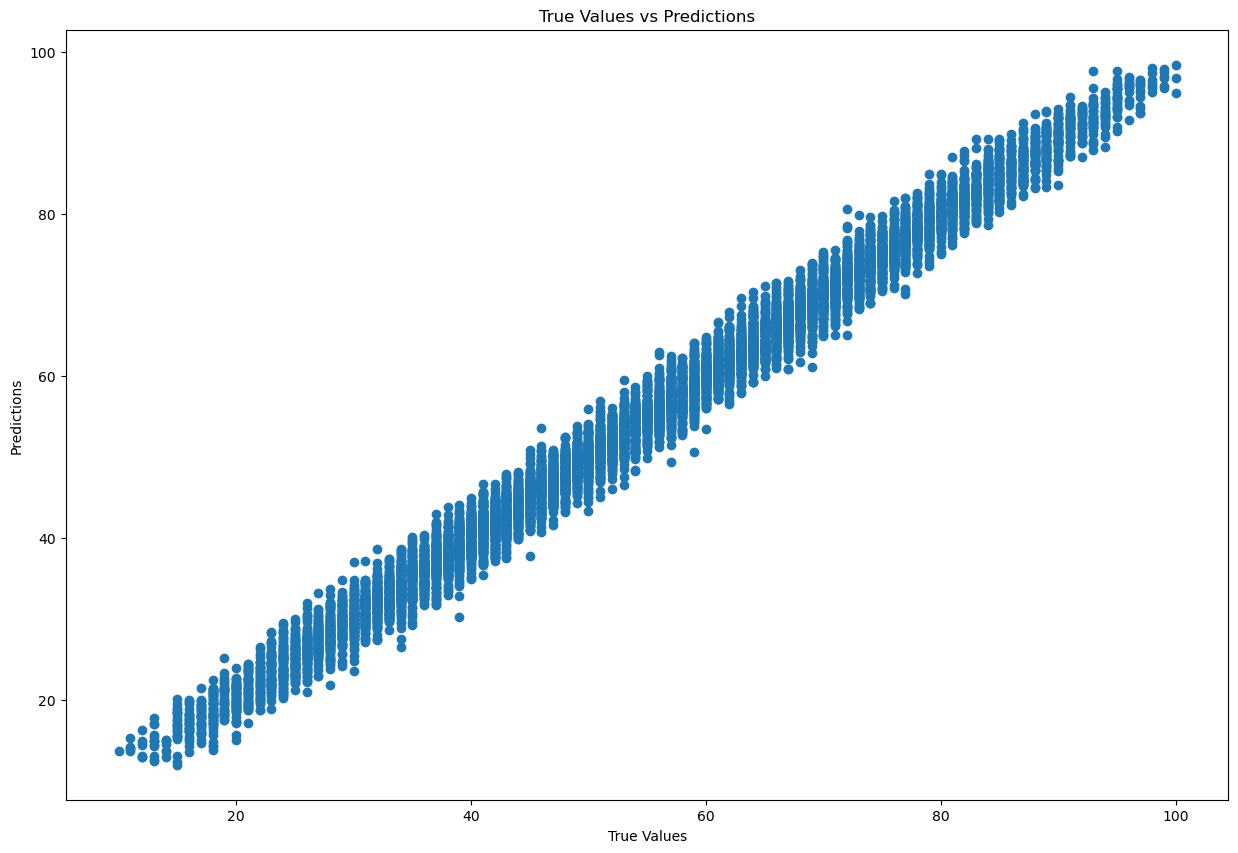

In [298]:
plt.figure(figsize=(15, 10))
plt.scatter(target, predictions)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True Values vs Predictions")
plt.show()

In [299]:
user_input = []
user_input.append(float(input("Enter hours studied: ")))
user_input.append(float(input("Enter previous scores: ")))
user_input.append(float(input("Enter sleep hours: ")))
user_input.append(float(input("Enter number of sample question papers practiced: ")))
user_input.append(float(input("Did the student participate in extracurricular activities? (1 for Yes, 0 for No): ")))
user_input = np.array(user_input)
user_input[:4] = (user_input[:4] - means) / stds
user_input = np.hstack(([1], user_input))
predicted_performance_index = user_input @ weights
print(f"Predicted Performance Index: {predicted_performance_index}")

Predicted Performance Index: 88.48929579358483
